# CN 指数法筛选 (CN index screening)

独立方法一：使用论文标准的 CN3839 / CN4142 / CH4300 谱指数，对冻结的 XGB threshold 候选星逐颗量化 CN 双带增强显著性。项目旧宽波段定义仅作为 `project_` 敏感性对照，严格分列。主筛选放宽到 1σ（CN3839 与 CN4142 的均值/标准差 z 同时 ≥ 1.0）；1.5/2.0/2.5σ 作为并行分级报告。CH4300 不并入总分，只用于标记 CH-normal-like / CH-strong-like。

## 1. 环境与输入边界

解释器固定为 `myenv`。候选成员唯一权威来源为 `XGB/XGB_PU_candidates_threshold.csv`；`PhaseSummary/03_ML_XGB/...` 只在 UID 集合严格相等时补充 `xgb_pu_score`。任一一致性失败都会停止。

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "feature" else NOTEBOOK_DIR
for p in (str(NOTEBOOK_DIR), str(PROJECT_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)

import cn_common as cc
import cn_index_screening as ci

print("python:", sys.executable)
print("notebook dir:", NOTEBOOK_DIR)

python: D:\Anaconda\envs\myenv\python.exe
notebook dir: D:\资料\2026大创\Lamost\feature


## 2. 冻结候选输入与 UID 一致性

In [2]:
inputs = cc.load_and_validate_inputs()
print("candidate rows:", len(inputs.candidates))
print("unique uids:", inputs.candidates["uid"].nunique())
print("xgb score missing:", int(inputs.candidates["xgb_pu_score"].isna().sum()))
display(inputs.candidates.head())
assert len(inputs.candidates) == 654
assert inputs.candidates["uid"].nunique() == 654

candidate rows: 654
unique uids: 654
xgb score missing: 0


,uid,ra,dec,teff,logg,feh,label,snru,xgb_pu_std,masked_cluster_id,xgb_pu_score
0,G14417857215136,258.532204,26.890513,4485.02,0.905,-1.557,-1,38.88,0.005412,34,0.984312
1,G14115435813304,319.932960,18.358957,4920.05,2.255,-1.243,-1,60.95,0.005783,34,0.983672
2,G15801615940186,104.362394,55.719890,4437.85,0.890,-1.783,-1,45.54,0.024899,31,0.983298
3,G14866615886127,191.659997,7.423810,4904.80,1.935,-1.957,-1,49.10,0.035279,25,0.982810
4,G14502126087737,248.593692,23.235639,4956.85,2.472,-0.984,-1,14.73,0.029914,9,0.982755


## 3. DR13-all 缓存与母样本

`X_clean` 为 3800–4499 Å 连续谱归一化光谱；已知 CN 星由 `label == 1` 标记，并在参考池中排除。

In [3]:
cache = cc.load_cache()
print("X_clean:", cache["X_clean"].shape)
print("stars_clean rows:", len(cache["stars_clean"]))
print("common_wave:", float(cache["common_wave"][0]), float(cache["common_wave"][-1]), float(cache["common_wave"][1] - cache["common_wave"][0]))
n_known = int((cache["stars_clean"]["label"] == 1).sum())
print("known CN:", n_known)
assert n_known == 91

从 dr13_all_cache 加载:
  X_clean:      (41243, 700)
  stars_clean:  41,243 行
  feature_df:   (41243, 20)
  已知 CN 星:   91
X_clean: (41243, 700)
stars_clean rows: 41243
common_wave: 3800.0 4499.0 1.0
known CN: 91


## 4. 执行指数法（计算 → 筛选 → 导出）

`run_index_screening` 复用 `cn_common` 的共享参考池构造、标准/项目指数计算与 1.0/1.5/2.0/2.5σ 分级，写入 `feature/results_index/` 下三类文件：候选星表 CSV、Top30 光谱图、方法与参数摘要 JSON。

In [4]:
res = ci.run_index_screening(output_dir=cc.RESULTS_INDEX_DIR, verbose=True)
cand_df = res["candidates"]
known_df = res["known"]
print("candidate feature rows:", len(cand_df))
print("known feature rows:", len(known_df))
assert len(cand_df) == 654 and len(known_df) == 91

从 dr13_all_cache 加载:
  X_clean:      (41243, 700)
  stars_clean:  41,243 行
  feature_df:   (41243, 20)
  已知 CN 星:   91


  targets: candidates=654, known CN=91, normal refs=30128


[index] candidates=654  known=91
  tier>=1p0: candidates=159  known_recall=0.418 (n_pass=38/91)
  tier>=1p5: candidates=83  known_recall=0.242 (n_pass=22/91)
  tier>=2p0: candidates=28  known_recall=0.143 (n_pass=13/91)
  tier>=2p5: candidates=10  known_recall=0.077 (n_pass=7/91)
[index] wrote cn_index_candidates.csv, top30_index_candidates.png, cn_index_summary.json
candidate feature rows: 654
known feature rows: 91


## 5. 多阶段分级与已知 CN 召回

报告各档（1.0/1.5/2.0/2.5σ）候选数量与已知 91 颗星的召回率（不只候选数）。`grade_*` 为 CN3839 与 CN4142 同时达标的布尔分级；robust z 并行算作备用。

In [5]:
for label in ("1p0", "1p5", "2p0", "2p5"):
    c = int(cand_df[f"grade_{label}"].sum())
    k = float(known_df[f"grade_{label}"].mean())
    print(f"tier>={label}: candidates={c}  known_recall={k:.3f} (n_pass={int(known_df[f'grade_{label}'].sum())}/{len(known_df)})")
print("CH class (candidates):")
display(cand_df["ch_class"].value_counts(dropna=False))

tier>=1p0: candidates=159  known_recall=0.418 (n_pass=38/91)
tier>=1p5: candidates=83  known_recall=0.242 (n_pass=22/91)
tier>=2p0: candidates=28  known_recall=0.143 (n_pass=13/91)
tier>=2p5: candidates=10  known_recall=0.077 (n_pass=7/91)
CH class (candidates):


ch_class
ambiguous         495
CH-normal-like    149
CH-strong-like     10
Name: count, dtype: int64

## 6. 候选星示例（主筛选 ≥1σ，按 XGB 分数排序）

In [6]:
cols = ["uid", "xgb_pu_score", "teff", "logg", "feh", "snru", "masked_cluster_id",
        "std_cn3839", "std_cn4142", "std_ch4300",
        "std_cn3839_z", "std_cn4142_z", "std_ch4300_z",
        "project_cn3839", "project_cn4142", "grade_1p0", "grade_2p0", "ch_class",
        "n_reference_members", "reference_quality"]
display(cand_df[cand_df["grade_1p0"]][cols].sort_values("xgb_pu_score", ascending=False).head(15))

,uid,xgb_pu_score,teff,logg,feh,snru,masked_cluster_id,std_cn3839,std_cn4142,std_ch4300,std_cn3839_z,std_cn4142_z,std_ch4300_z,project_cn3839,project_cn4142,grade_1p0,grade_2p0,ch_class,n_reference_members,reference_quality
0,G14417857215136,0.984312,4485.02,0.905,-1.557,38.88,34,0.484497,0.016063,0.177976,2.069851,1.562989,-0.151370,0.349558,0.016063,True,False,CH-normal-like,50,good
3,G14866615886127,0.982810,4904.80,1.935,-1.957,49.10,25,0.783688,0.036228,0.151626,2.189273,2.416649,-2.494163,0.510853,0.036228,True,True,CH-normal-like,50,good
4,G14502126087737,0.982755,4956.85,2.472,-0.984,14.73,9,0.769307,0.009086,0.167244,5.266443,1.710669,-1.613768,0.548714,0.009086,True,False,CH-normal-like,50,good
8,L14327934924837,0.980989,4504.52,1.026,-1.868,22.75,20,0.490686,0.028387,0.163481,4.857890,1.834378,0.192373,0.329117,0.028387,True,False,CH-normal-like,50,good
10,G16369423799359,0.979764,4428.72,0.932,-1.744,17.60,9,0.540274,0.019040,0.153994,1.302102,1.862536,-2.560202,0.398709,0.019040,True,False,CH-normal-like,50,good
11,L15968094080310,0.979667,4773.54,1.877,-1.065,6.13,7,0.891532,0.025697,0.171416,5.724872,3.966400,-2.501825,0.661760,0.025697,True,True,CH-normal-like,50,good
13,L14341383656115,0.978208,5107.44,2.500,-1.343,25.71,20,0.363324,0.026465,0.099913,1.794819,2.525097,-2.533358,0.295382,0.026465,True,False,CH-normal-like,50,good
19,G13889826793626,0.974985,4839.70,2.031,-1.207,7.91,34,0.515866,0.022382,0.146551,2.447649,1.714712,-1.244858,0.346193,0.022382,True,False,CH-normal-like,50,good
20,G15263068931183,0.974651,4781.49,2.369,-0.831,9.84,7,0.717985,-0.001745,0.174696,4.175752,1.127118,-2.662746,0.564964,-0.001745,True,False,CH-normal-like,50,good
21,L15633295607629,0.974266,4938.72,2.380,-1.032,82.57,9,0.654420,0.007822,0.181886,3.448186,1.576188,-0.553568,0.478083,0.007822,True,False,CH-normal-like,50,good


## 7. 导出文件、摘要与 Top30 光谱图

In [7]:
print("written files:")
for key, path in res["paths"].items():
    print(f"  {key}: {path}")
summary = json.loads(Path(res["paths"]["summary"]).read_text(encoding="utf-8"))
print(json.dumps({
    "candidate_count": summary["candidate_count"],
    "reference_quality": summary["reference_quality"],
    "tier_counts": summary["tier_counts"],
    "known_recall": summary["known_recall"],
    "primary_screening": summary["primary_screening"],
    "limitations": summary["limitations"],
}, ensure_ascii=False, indent=2))

written files:
  candidates: D:\资料\2026大创\Lamost\feature\results_index\cn_index_candidates.csv
  plot: D:\资料\2026大创\Lamost\feature\results_index\top30_index_candidates.png
  summary: D:\资料\2026大创\Lamost\feature\results_index\cn_index_summary.json
{
  "candidate_count": 654,
  "reference_quality": {
    "good": 653,
    "descriptive_only": 1
  },
  "tier_counts": {
    "1p0": {
      "candidate_cn_dual_pass": 159,
      "candidate_cn_dual_pass_robust": 222,
      "candidate_cn_dual_pass_project": 158
    },
    "1p5": {
      "candidate_cn_dual_pass": 83,
      "candidate_cn_dual_pass_robust": 140,
      "candidate_cn_dual_pass_project": 76
    },
    "2p0": {
      "candidate_cn_dual_pass": 28,
      "candidate_cn_dual_pass_robust": 78,
      "candidate_cn_dual_pass_project": 30
    },
    "2p5": {
      "candidate_cn_dual_pass": 10,
      "candidate_cn_dual_pass_robust": 42,
      "candidate_cn_dual_pass_project": 10
    }
  },
  "known_recall": {
    "1p0": {
      "recall": 0.417582

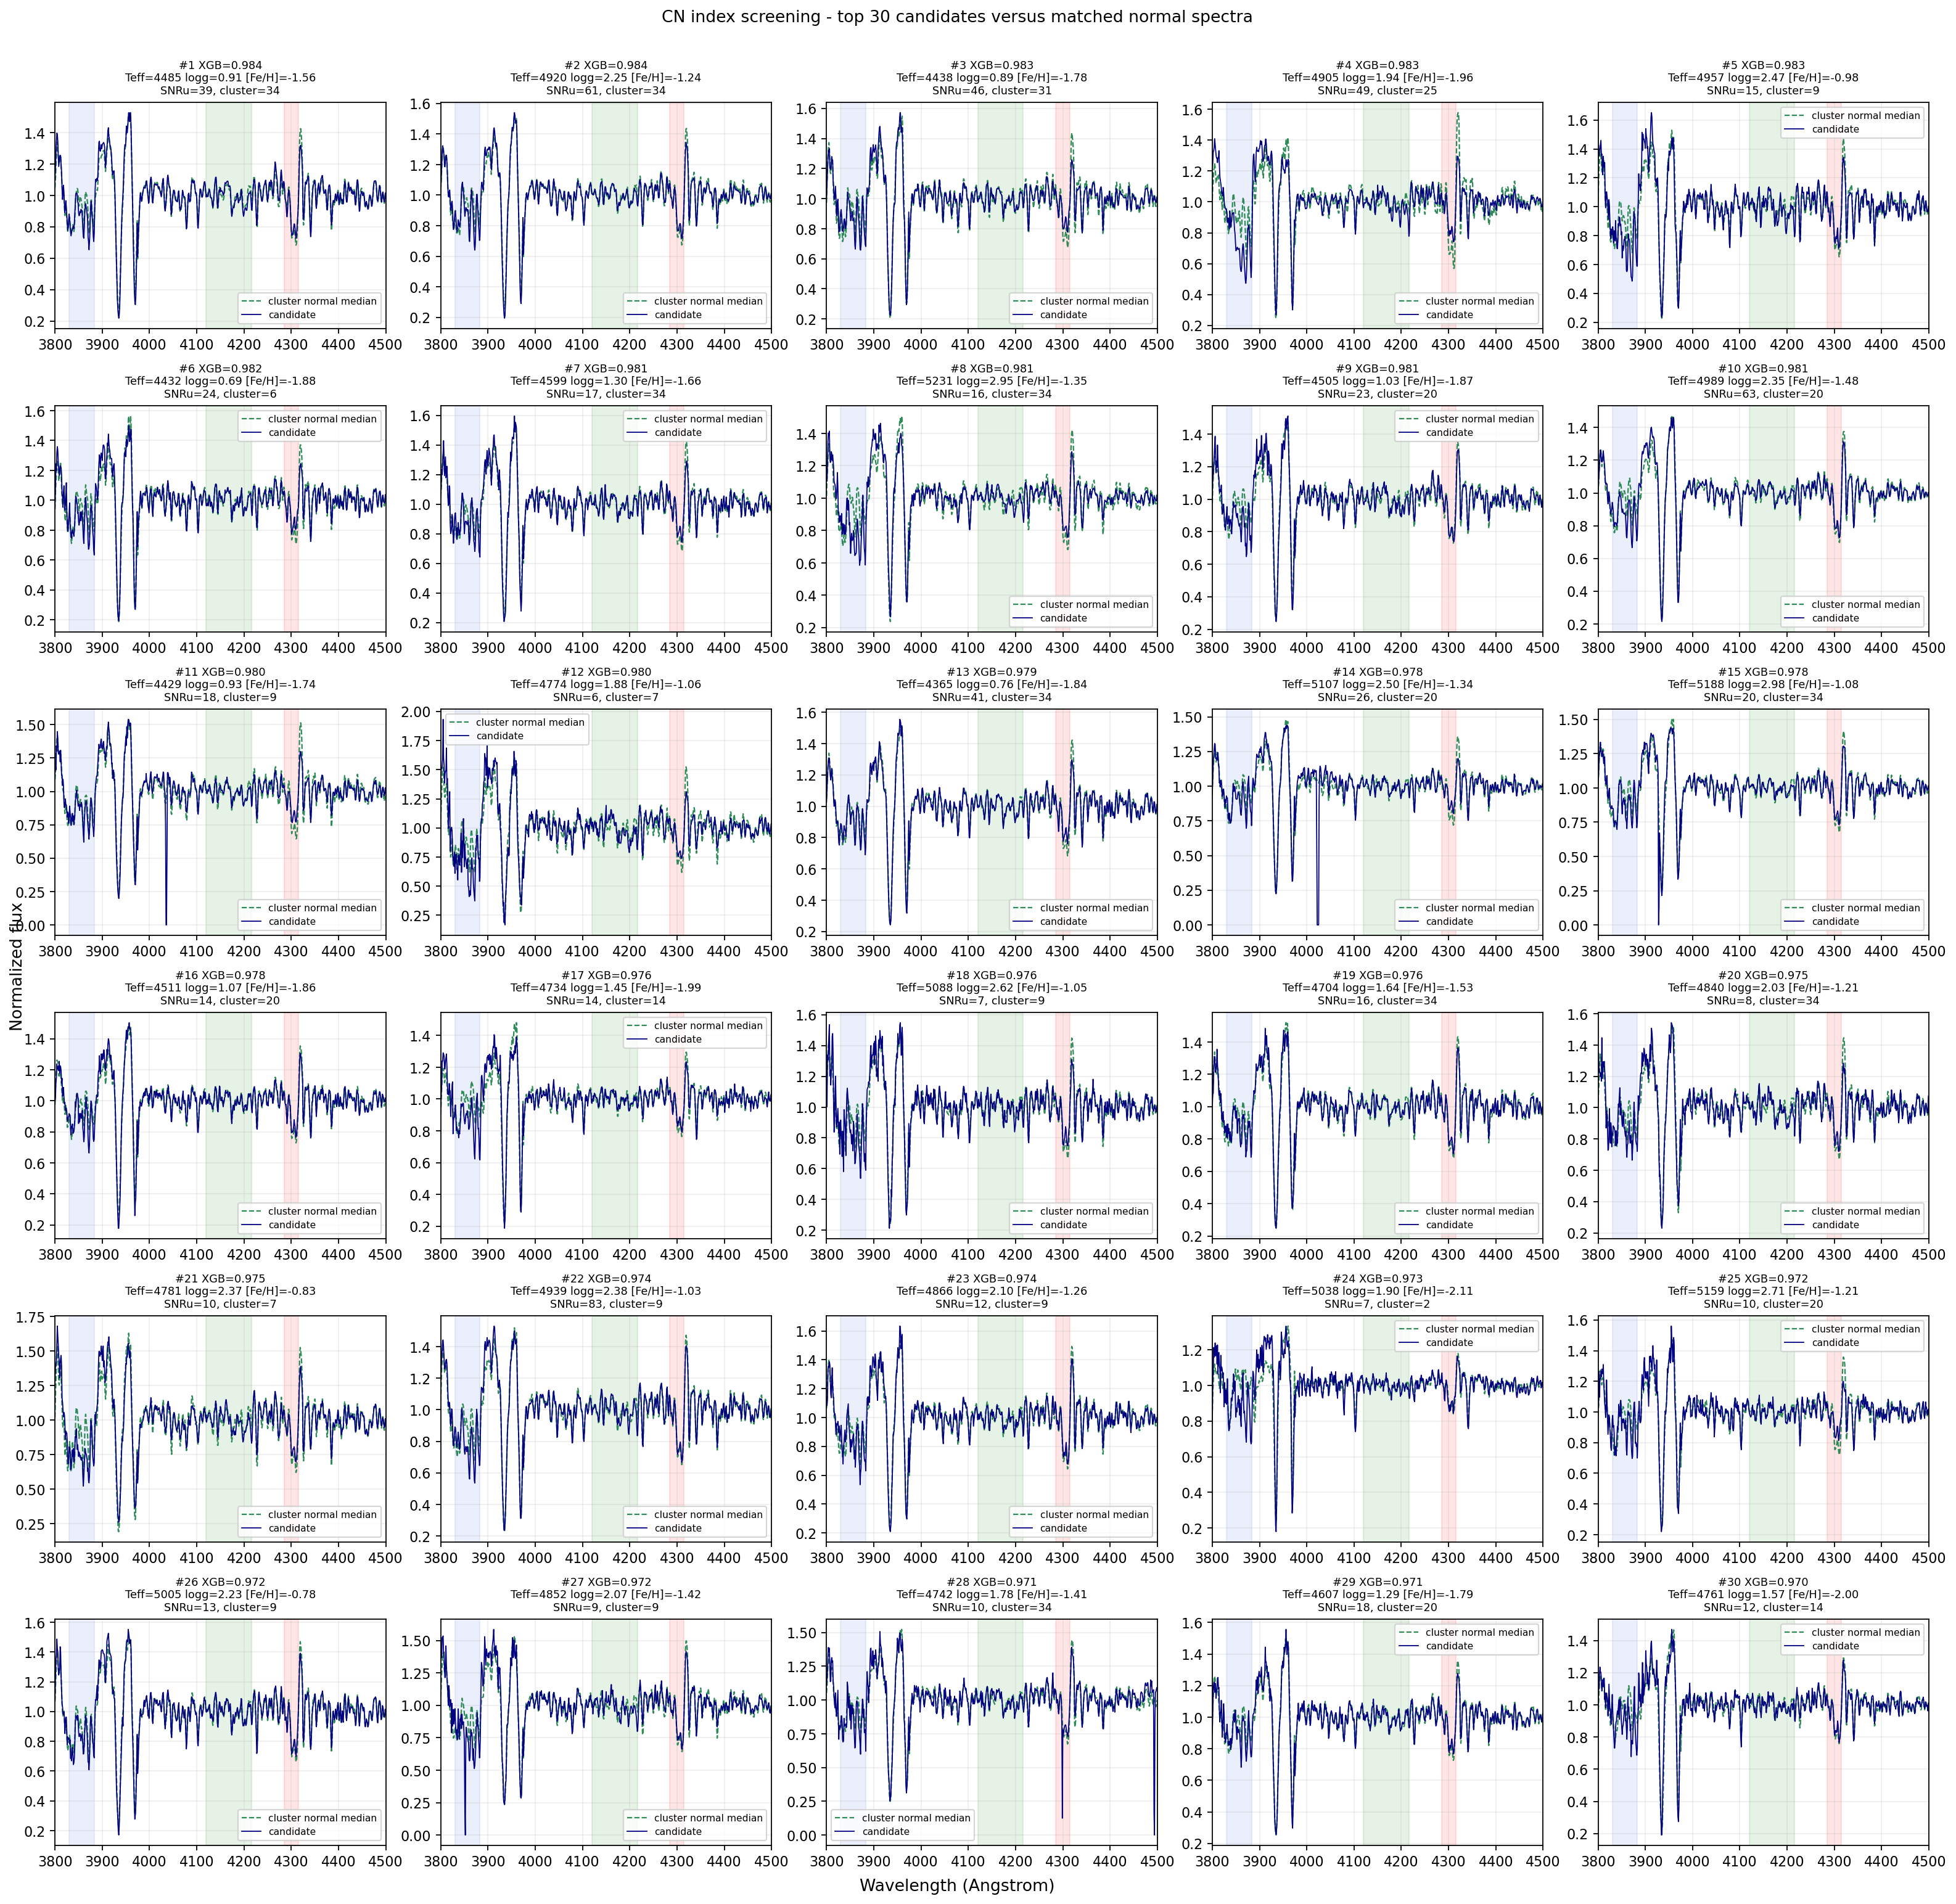

In [8]:
display(Image(filename=str(res["paths"]["plot"]), width=1100))